# Import the Dependencies 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import  RandomForestRegressor
from sklearn import  metrics
import seaborn as sns

# Data collection and processing 

In [2]:
# loading the csv data to a pandas dataframe
gold_data = pd.read_csv("./sample_data/gld_price_data.csv")

In [3]:
# First five rows
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
# print the last 5 rows of the data frame
gold_data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [5]:
# Number of rows and columns
gold_data.shape

(2290, 6)

In [6]:
# getting some basic info about the data
gold_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
# Getting the statitical values
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [8]:
# Check the number of missing values
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

# Correlation
* Positive correlation
* Negative Correlation

In [9]:
correlation = gold_data.corr(numeric_only=True)

correlation

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


<Axes: >

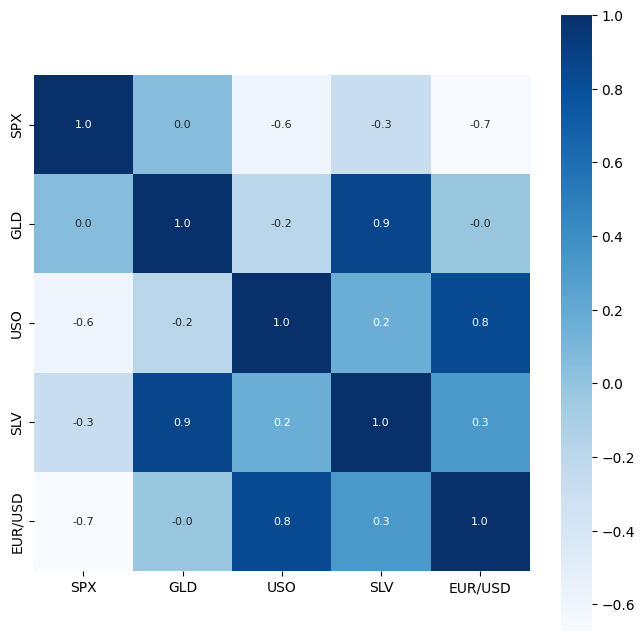

In [10]:
# Constructing a heatmap to understand the correlation

plt.figure(figsize= (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size': 8}, cmap='Blues')

In [11]:
# Correlation values of GLD
print(correlation['GLD'])


SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_12172\995727493.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='green')


<Axes: xlabel='GLD', ylabel='Density'>

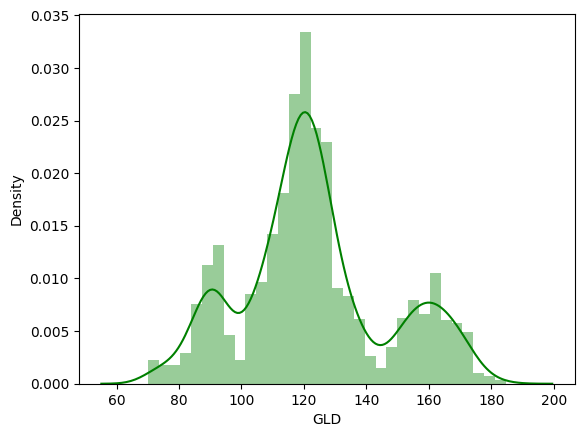

In [16]:
# check the distribution of the gold price
sns.distplot(gold_data['GLD'], color='green')

# splitting the features and the target 

In [19]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
Y = gold_data['GLD']

In [20]:
print(X)
print(Y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


# splitting into train data and test data 

In [22]:
X_train, X_test, Y_train, Y_test =  train_test_split(X, Y, test_size=0.2, random_state=2)

# Model training:
### Using random forest regressor

In [23]:
regressor = RandomForestRegressor(n_estimators=100)

In [25]:
# Training the model
regressor.fit(X_train, Y_train)

RandomForestRegressor()

# Model Evaluation


In [26]:
# Prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [27]:
print(test_data_prediction)

[168.82199966  82.11039973 116.15980014 127.86230069 120.81990085
 154.77589781 150.23999901 126.16130063 117.56049859 126.08400029
 116.76350114 171.45080079 141.3981983  167.78219823 115.24310034
 117.76410036 139.0886032  170.36790105 159.46100304 157.65919896
 155.07989998 125.25109994 176.09310009 157.61030367 125.23790041
  94.01989975  77.33360038 120.50209975 119.15939946 167.45670015
  88.16750084 124.99429996  91.19090123 117.63379998 121.17639911
 137.40500051 115.47010099 115.20670043 148.26550016 107.00250069
 104.65240243  87.19759801 126.38360064 117.6908996  154.55189909
 119.6503     108.4100998  108.07699852  93.23760077 127.10719812
  75.0170002  113.53679911 121.34080032 111.30669959 118.89409891
 120.72099948 159.48079997 168.01820113 147.0171968   85.81879832
  94.58130028  86.74719877  90.51120044 118.96360071 126.54280052
 127.51400024 168.98669964 122.30169903 117.29879882  98.3557003
 168.175501   143.03949831 132.47240129 121.26410215 121.30759912
 119.795900

In [28]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)

In [30]:
print("R squared error:", error_score)

R squared error: 0.9887917537153785


# Compare the actual values and the predicted values in a plot 

In [31]:
Y_test = list(Y_test)

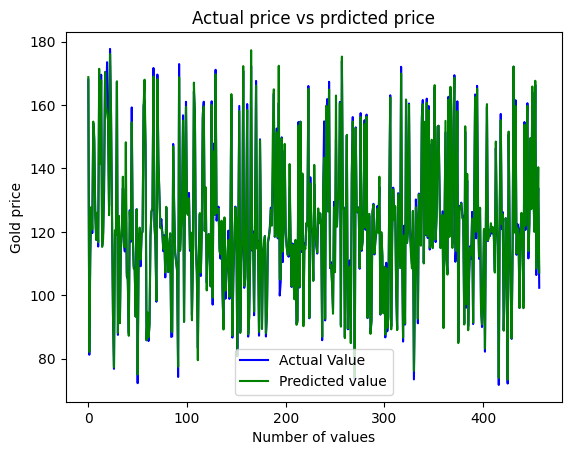

In [36]:
plt.plot(Y_test, color='blue', label="Actual Value")
plt.plot(test_data_prediction, color='green', label="Predicted value")
plt.title("Actual price vs prdicted price")
plt.xlabel('Number of values')
plt.ylabel('Gold price')
plt.legend()
plt.show()